Notebook to test noise scaling of the simulator

In [1]:
# Standard libraries
import numpy as np
import json
import os, sys, importlib
from typing import List
import matplotlib.pyplot as plt

# Qiskit
from qiskit.visualization import plot_histogram
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.controlflow import ControlFlowOp
from qiskit.result import marginal_counts
from qiskit.transpiler import CouplingMap, Layout
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit_ibm_runtime.fake_provider import FakeBrisbane
  # try other Fake*V2 if needed

# Point to the *parent* of the package folder
#LOCAL_QG_PATH = r"..\src"   # or r"C:\path\to\your\local\quantum-gates\src"
LOCAL_QG_PATH = os.path.abspath("../src")

LOCAL_QG_PATH = os.path.abspath(LOCAL_QG_PATH)

# Put local src at the very front of sys.path
if LOCAL_QG_PATH in sys.path:
    sys.path.remove(LOCAL_QG_PATH)
sys.path.insert(0, LOCAL_QG_PATH)

# Purge any cached copies of the package
for m in list(sys.modules):
    if m == "quantum_gates" or m.startswith("quantum_gates."):
        del sys.modules[m]

# Invalidate import caches and import the local package
importlib.invalidate_caches()
import quantum_gates
from quantum_gates.utilities import DeviceParameters

print("Using quantum_gates from:", quantum_gates.__file__)

# Own library
from quantum_gates.utilities import fix_counts
from quantum_gates.simulators import MrAndersonSimulator
from quantum_gates.gates import standard_gates
from quantum_gates.circuits import EfficientCircuit, BinaryCircuit, Circuit
from quantum_gates.utilities import DeviceParameters
from quantum_gates.utilities import setup_backend

    

Using quantum_gates from: /Users/b753yl/Desktop/CERN - Quantum Gates/quantum-gates/src/quantum_gates/__init__.py


In [2]:

def build_2_qubit_x_circuit(
    input_state=None,
    x_qubit=0,
    AER_boolean=False,
):
    """
    Build a simple 2-qubit circuit with an X gate on one qubit.

    Args:
        input_state: optional Statevector to initialize the circuit
        x_qubit (int): which qubit to apply X to (0 or 1)
        AER_boolean (bool): whether to save statevector using Aer
    """
    N_q = 2
    qc = QuantumCircuit(N_q, N_q)

    # Optional state initialization (Aer only)
    if AER_boolean and input_state is not None:
        qc.set_statevector(input_state)

    qc.barrier()

    # Apply X gate
    qc.x(x_qubit)
    qc.barrier()
    qc.x(x_qubit)

    qc.barrier()

    # Save statevector if using Aer
    if not AER_boolean:
        qc.barrier(label=f"save_sv_after_X_1")
    else:
        qc.save_statevector(label=f"save_sv_after_X_1")  #


    # Final measurement
    qc.measure(range(N_q), range(N_q))

    return qc


In [3]:
N_q = 2
qc = build_2_qubit_x_circuit(x_qubit=0, AER_boolean=False)

initial_state = np.zeros(2**N_q)
initial_state[0] = 1.0  # set |00...0⟩
initial_layout = list(range(N_q))  # logical qubit 0→physical 0, 1→1, etc.

initial_psi = initial_state



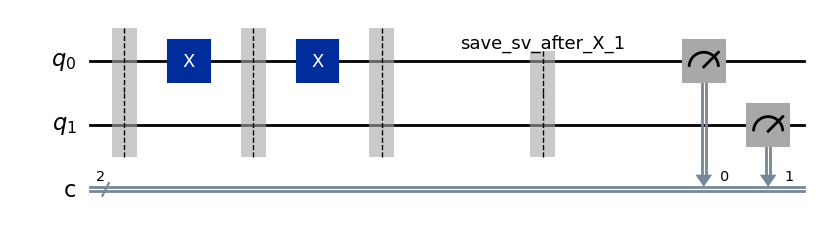

In [4]:
qc.draw(output="mpl", fold=-1, plot_barriers =True)


In [5]:
# Pick a fake backend for device parameters
backend = FakeBrisbane()  # 127 qubits; change to another Fake*V2 if import fails

# 2) Use only N qubits
qubits_layout = list(range(N_q))

# 3) Load via YOUR class and save JSON next to the script
device_param = DeviceParameters(qubits_layout)
device_param.load_from_backend(backend)
device_param_lookup = device_param.__dict__()
#device_param.save_to_json("./")  # writes ./device_parameters.json
#print("Wrote ./device_parameters.json")

In [6]:
# Transpile circuit
needs_controlflow = any(isinstance(op.operation, ControlFlowOp) for op in qc.data)

t_circ = transpile(
    qc,
    backend,
    initial_layout=qubits_layout,
    seed_transpiler=42,
    **({} if needs_controlflow else {"scheduling_method": "asap"})
)

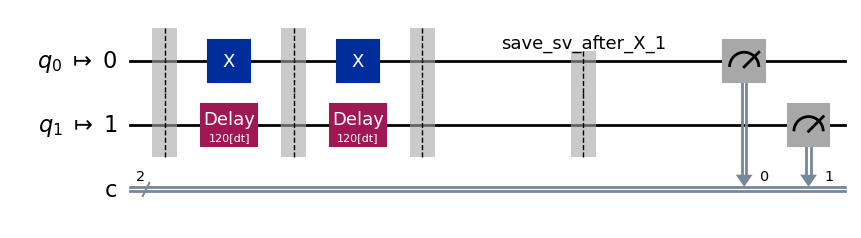

In [7]:
t_circ.draw('mpl')

In [8]:
# call the Noisy simulator
#sim = MrAndersonSimulator(gates=standard_gates, CircuitClass=EfficientCircuit)

'''
# For Noise free simulation
from quantum_gates.gates import NoiseFreeGates 
sim = MrAndersonSimulator(
    gates=NoiseFreeGates(),        # <- ideal gates (no noise)
    CircuitClass=EfficientCircuit
)
'''

'''
# Scaled Noise simulation
from quantum_gates.gates import ScaledNoiseGates 
overall_noise_scaling=1.5


sim = MrAndersonSimulator(
    gates=ScaledNoiseGates(noise_scaling=overall_noise_scaling),        # <- ideal gates (no noise)
    CircuitClass=EfficientCircuit
)
'''

'''
from quantum_gates.gates import CustomNoiseGates
low_pauli_noise_gates = CustomNoiseGates(
    p_scale=0.1,
    T1_scale=1.0,
    T2_scale=1.0,
)
sim = MrAndersonSimulator(
    gates=low_pauli_noise_gates,     # <- ideal gates (no noise)
    CircuitClass=EfficientCircuit
)
'''


from quantum_gates.gates import CustomNoiseChannelsGates
custom_channel_gates = CustomNoiseChannelsGates(
    noiseless_qubits=[1],  # qubits with no noise channels
    p_scale=100.0,
    T1_scale=100.0,
    T2_scale=100.0,
)
sim = MrAndersonSimulator(
    gates=custom_channel_gates,     # <- ideal gates (no noise)
    CircuitClass=EfficientCircuit
)


bit_flip_bool = False # turn on/off for readout noise

shots = 100

In [10]:


# Run simulation
res  = sim.run( 
    t_qiskit_circ=t_circ, 
    psi0=initial_psi, 
    shots=shots, 
    device_param=device_param_lookup,
    nqubit=N_q,
    bit_flip_bool=bit_flip_bool,
    )

# get results
probs = res["probs"]
results = res["results"]
num_clbits = res["num_clbits"]

mid_counts = res["mid_counts"]


#print("Mid-circuit measurement results", results)
print("Number of classical bits in circuit:", num_clbits)
print("Mid-circuit measurement counts:", mid_counts)

Number of classical bits in circuit: 2
Mid-circuit measurement counts: {'00': 100}


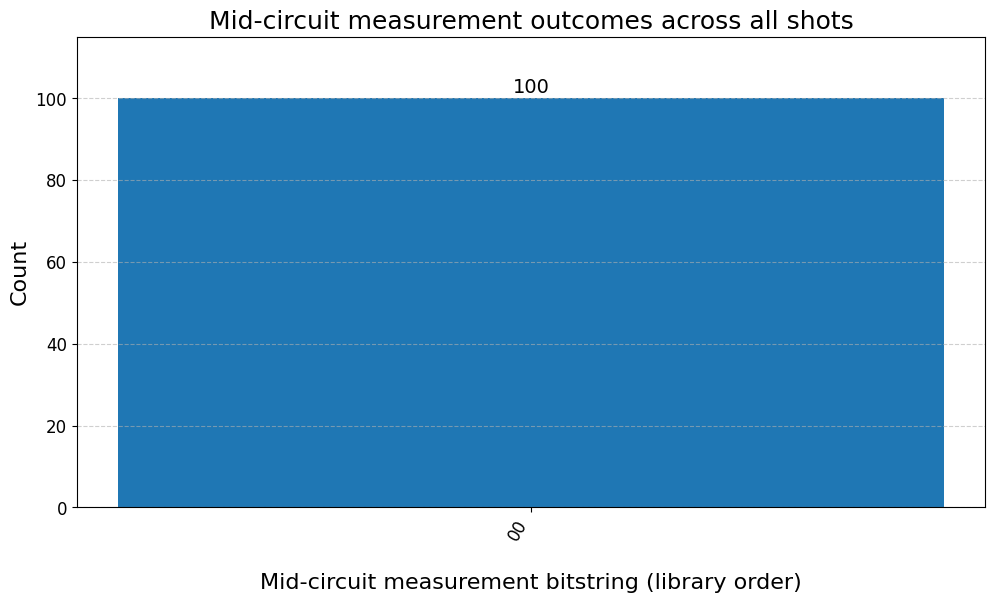

Mid-circuit measurement counts: {'00': 100}


In [11]:

# --- Plot histogram ---
labels = sorted(mid_counts.keys())
values = [mid_counts[k] for k in labels]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color="#1f77b4")  # same default Aer blue

# Extend y-axis a bit to fit annotations
max_val = max(values)
plt.ylim(0, max_val * 1.15)

# Annotate bar tops
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
             ha='center', va='bottom', fontsize=14, color="black")

plt.xlabel("\nMid-circuit measurement bitstring (library order)", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.title("Mid-circuit measurement outcomes across all shots",fontsize=18)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.yticks(fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=12)   # tilt x-axis labels

plt.show()

# --- Optional printout ---
print("Mid-circuit measurement counts:", dict(mid_counts))

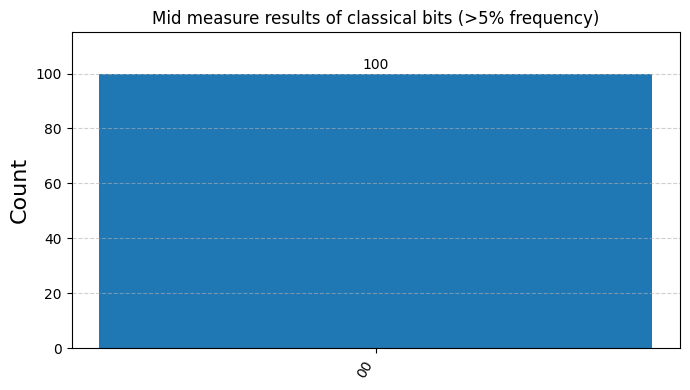

In [12]:
threshold = 0.05 * shots  # 5% cutoff

# --- Filter ---
filtered_counts = {k: v for k, v in mid_counts.items() if v >= threshold}

# --- Sort by bitstring (optional) ---
filtered_labels = list(sorted(filtered_counts.keys()))
filtered_values = [filtered_counts[k] for k in filtered_labels]

# --- Plot ---
plt.figure(figsize=(7, 4))
bars = plt.bar(filtered_labels, filtered_values, color="#1f77b4")  # same default Aer blue

# Extend y-axis a bit to fit annotations
max_val = max(filtered_values)
plt.ylim(0, max_val * 1.15)

# Annotate bar tops
for bar, val in zip(bars, filtered_values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
             ha='center', va='bottom', fontsize=10, color="black")

# Match Aer-style axes
plt.ylabel("Count", fontsize=16)
plt.xlabel("")  # Aer histograms usually skip x-axis label
plt.title("Mid measure results of classical bits (>5% frequency)", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Tight layout to match Aer formatting
plt.tight_layout()
plt.show()

# AER test

In [ ]:
initial_state_qiskit = sv_normal_to_qiskit(initial_state)

In [ ]:
qc = build_4_Qubit_SC(cycles=cycles, input_state=initial_state_qiskit, AER_boolean=True)
qc.draw('mpl')


NameError: name 'build_4_Qubit_SC' is not defined

In [ ]:
# Simulate with Aer
#shots = 100
sim = AerSimulator()
t_qc = transpile(qc, sim)

result = sim.run(qc, shots=shots).result()
counts = result.get_counts()

In [ ]:
Aer_svs = {}
for label in result.data().keys():
    Aer_svs[label] = result.data()[label]

In [ ]:
Aer_svs

In [ ]:
AER_trans_save_qubit_orders = extract_qubit_orders(t_qc, instruction_type="save_statevector")
print(AER_trans_save_qubit_orders)

In [ ]:
AER_order_dict = dict(AER_trans_save_qubit_orders)
AER_result_dict = Aer_svs

AER_logical_svs = {}

for label, sv in AER_result_dict.items():
    if label == "counts":
        continue
    if label not in AER_order_dict:
        continue

    AER_logical_svs[label] = permute_qiskit_sv_to_logical(
        sv.data if hasattr(sv, "data") else sv,
        AER_order_dict[label]
    )

In [ ]:
AER_logical_svs

In [ ]:

fidelities = {
    label: state_fidelity(initial_state, sv)
    for label, sv in AER_logical_svs.items()
}

print(fidelities)
